In [48]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/simulations/Leaflet


In [49]:
import sys
sys.path.append('../../utils')
from functions import * 

In [50]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [51]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

<module 'cell_state_asign_consistency' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/cell_state_asign_consistency.py'>

In [52]:
import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

<module 'betabinomo_mix_singlecells' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py'>

In [53]:
from importlib import reload
from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline, geom_density
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

### Settings and Load data

In [54]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 5 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., # karin had 0.65 
    "pi_prior" : 1.
}

cpu


In [55]:
hypers["eta"]

0.2

### load_cluster_data takes ~ 5 minutes for ss2 brain data.... 

In [56]:
# this folder contains input data for each tissue cell type sample
input_file = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/Psix/simulated_junc_counts.h5'

# load the file that has positive/negative labels for genes expected to have cell state associated splicing patterns 
splicing_genes = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/Psix/gene_psi_labels.csv")

final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
    input_file = input_file) 

Reading in data from folder ...
Finished reading in data from folder ...
['3_1' '3_2']
1000
14975
The number of junctions in the data is:  14976
The number of cells in the data is:  1000
The number of cell types in the data is:  2


In [57]:
# read in input_file as pandas dataframe
full_data = pd.read_hdf(input_file, key = 'df')
full_data.head() 

,cell_id,junction_id,cell_type,cell_id_index,junction_id_index,junc_count,Cluster_Counts,Cluster,junc_ratio,label,gene
0,cell_1,gene1_I1,3_1,0,3326,3,13,0,0.230769,positive,gene1
2,cell_3,gene1_I1,3_1,223,3326,6,9,0,0.666667,positive,gene1
3,cell_4,gene1_I1,3_1,334,3326,4,18,0,0.222222,positive,gene1
6,cell_7,gene1_I1,3_1,667,3326,9,17,0,0.529412,positive,gene1
7,cell_8,gene1_I1,3_1,778,3326,10,18,0,0.555556,positive,gene1


In [58]:
#filter full_data to just the junctions in the final_data file and report number of unique genes this maps to 
len(full_data[full_data["junction_id_index"].isin(final_data["junction_id_index"])].gene.unique())

5000

In [59]:
# ensure that in coo_counts_sparse.shape = (n_cells, n_genes) , n_cells is the same number as cell_ids_conversion.shape = (n_cells, num_variables)
assert coo_counts_sparse.shape[0] == cell_ids_conversion.shape[0]

In [60]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
1000
1000


In [61]:
# set random seed
torch.manual_seed(0)

num_trials = 10 # should also be an argument that gets fed in
num_iters = 200 # should also be an argument that gets fed in

start_time = time.time()

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]

# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 1000 cells and J = 14976 junctions
Got the initial ELBO ^


ELBO converged @ -31818228.0 CAVI iteration # 17 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1000 cells and J = 14976 junctions
Got the initial ELBO ^
ELBO converged @ -31816708.0 CAVI iteration # 8 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1000 cells and J = 14976 junctions
Got the initial ELBO ^
ELBO converged @ -31815828.0 CAVI iteration # 26 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1000 cells and J = 14976 junctions
Got the initial ELBO ^
ELBO converged @ -31821852.0 CAVI iteration # 17 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1000 cells and J = 14976 junctions
Got the initial ELBO ^
ELBO converged @ -31819760.0 CAVI iteration # 24 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 1000 cells and J = 14976 junctions
Got the initial ELBO ^
ELBO converged @

### Evaluate how consistent the cell type assignments are across the trials of the mixture model

In [99]:
13.4/60 

0.22333333333333333

In [62]:
# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_types = cell_ids_conversion.cell_type.values
# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

Running! will make heatmap with cell types
Got all cells and their assignments based on PHI_f in each trial!
Got a cell by cell matrix for each trial indicating whether cells were coassigned
Getting sum of matrices across all iterations
The number of trials is:  10
    Value   Count
0     0.0  563730
9     9.0   60046
1     1.0   50118
10   10.0   48080
2     2.0   47156
8     8.0   46438
7     7.0   41016
4     4.0   37078
5     5.0   36908
6     6.0   36516


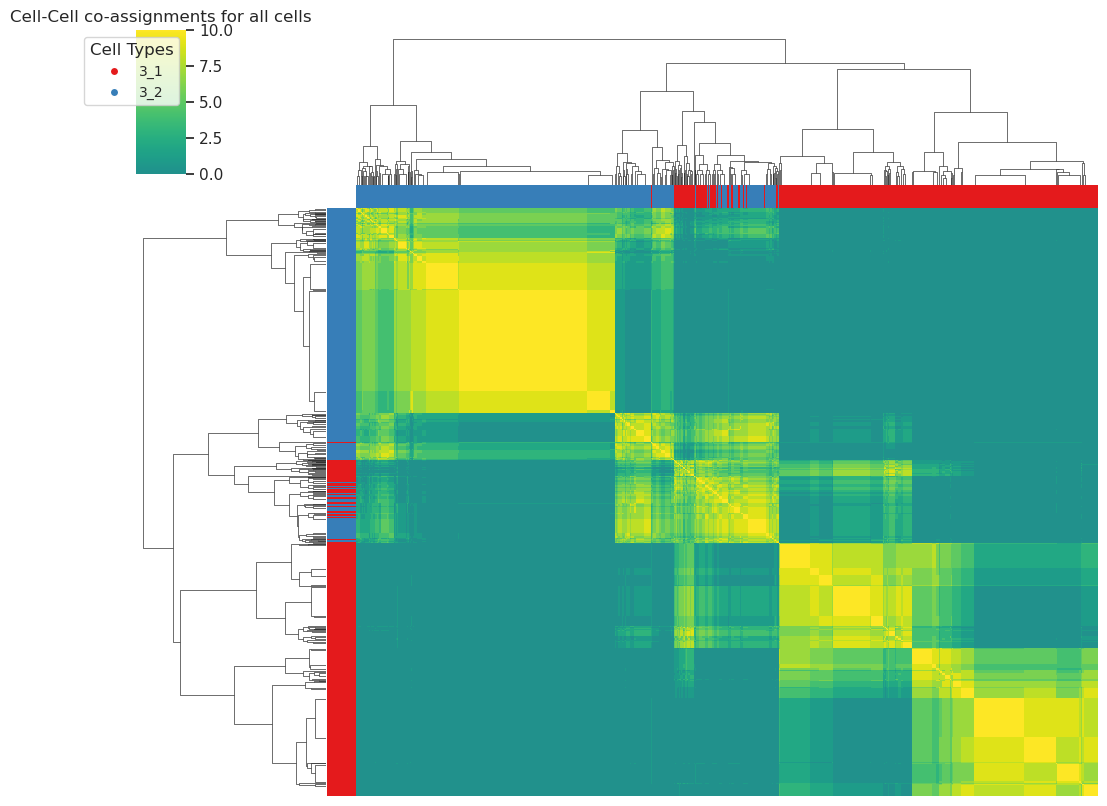

In [63]:
all_iters_results = check_cell_pairs(results, row_colors, col_colors, cell_type_colors)

### Evaluate the learned posteriors

The trial with the highest ELBO was 2


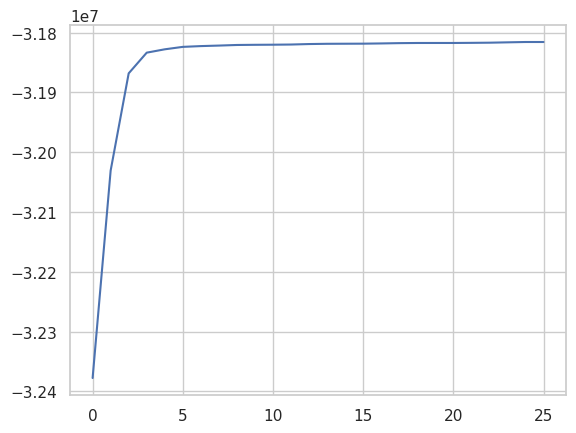

In [64]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

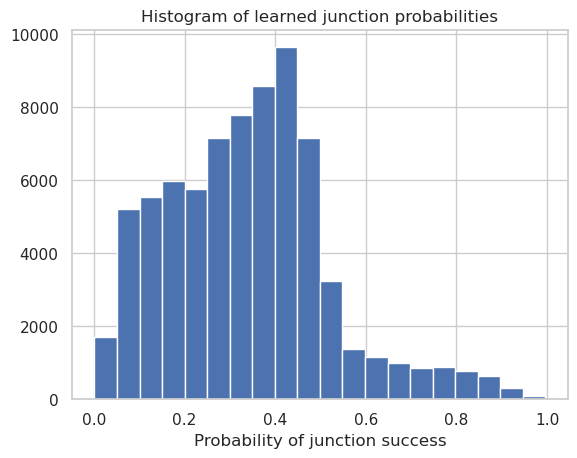

In [65]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
 
plt.hist(juncs_probs.cpu().numpy().flatten(), 20)
plt.title('Histogram of learned junction probabilities') 
plt.xlabel('Probability of junction success')
plt.show()

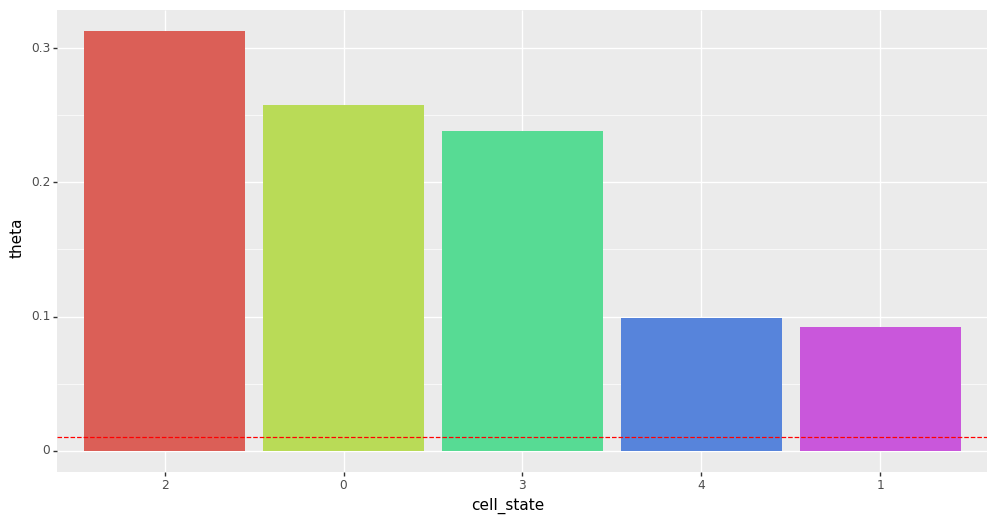

In [66]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)

sorted_cell_states = GAMMA_f_plot["cell_state"].astype(str)
GAMMA_f_plot["cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())

# make barplot and make it wider 
p9.options.figure_size = (12, 6)
p = (ggplot(GAMMA_f_plot, aes(x="cell_state", y="theta", fill="cell_state")) +
        geom_bar(stat="identity") + 
        theme(legend_position="none"))

# add a line at 0.01 (1%)
p = p + geom_hline(yintercept=0.01, linetype="dashed", color="red")
print(p)

In [67]:
# let's retain only the cell states that are used more than 5% of the time
GAMMA_f_plot = GAMMA_f_plot[GAMMA_f_plot["theta"] > 0.01]
GAMMA_f_plot.index.values

array([2, 0, 3, 4, 1])

In [68]:
# summarize PHI_f values, which are the probabilities of a cell belonging to each cell state 
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot.head()

,0,1,2,3,4
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0


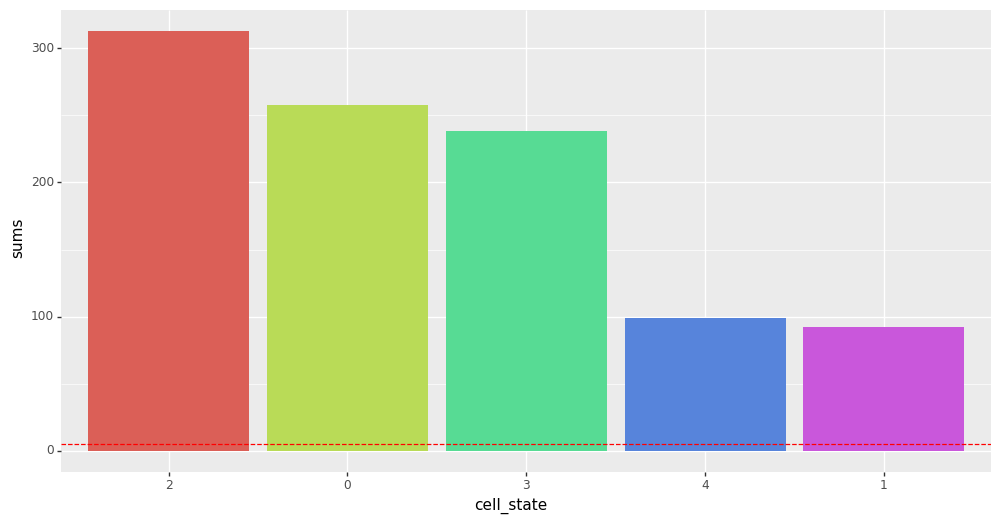

In [69]:
# find cols in PHI_f that have sums of zero 
PHI_sums = PHI_f.sum(axis=0)
# turn into a dataframe 
PHI_sums = pd.DataFrame(PHI_sums.cpu().numpy(), columns=["sums"])
PHI_sums["cell_state"] = PHI_sums.index

PHI_sums.sort_values(by="sums", ascending=False, inplace=True)
sorted_cell_states = PHI_sums["cell_state"].astype(str)
PHI_sums["cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())

# make barplot and make it wider 
p9.options.figure_size = (12, 6)
p = (ggplot(PHI_sums, aes(x="cell_state", y="sums", fill="cell_state")) +
        geom_bar(stat="identity") + 
        theme(legend_position="none"))

# add a line at 0.01 (1%)
p = p + geom_hline(yintercept=5, linetype="dashed", color="red")
print(p)

In [70]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,2,0,3,4,1
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0
996,1.0,0.0,0.0,0.0,0.0
997,1.0,0.0,0.0,0.0,0.0
998,1.0,0.0,0.0,0.0,0.0


In [71]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_7377/3052898343.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_0,CellState_1,CellState_2,CellState_3,CellState_4
cell_type,,,,,
3_1,0.000000,2.580000e+02,52.000000,99.0,92.000008
3_2,312.999969,2.076188e-38,186.000031,0.0,0.000000


/scratch/ipykernel_7377/344606641.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_7377/344606641.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


{'CellState_0': ('3_2', 0.627), 'CellState_1': ('3_1', 0.515), 'CellState_2': ('3_2', 0.373), 'CellState_3': ('3_1', 0.198), 'CellState_4': ('3_1', 0.184)}


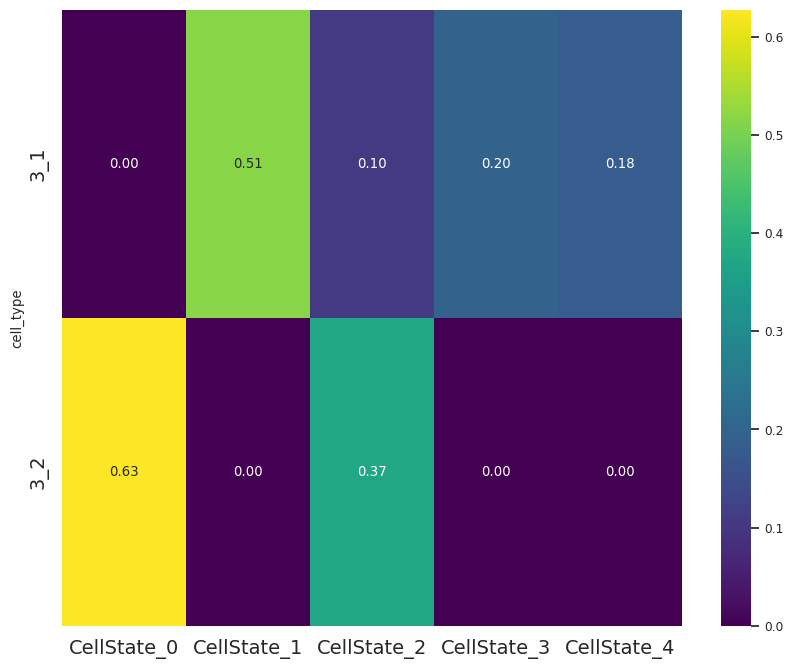

In [72]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(10, 8))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
sns.heatmap(sum_prop, annot=True, fmt=".2f", cmap='viridis')

# now let's give the cell states new labels based on what cell types they are associated with 
# go through sum_prop and for each cell state find the cell type with the highest proportion
# assign that cell type to the cell state
cell_type_labels = {}
for state in sum_prop.columns:
    max_prop = 0
    max_celltype = ''
    for celltype in sum_prop.index:
        if sum_prop.loc[celltype, state] > max_prop:
            max_prop = sum_prop.loc[celltype, state]
            max_celltype = celltype
    cell_type_labels[state] = max_celltype, round(max_prop, 3)
print(cell_type_labels)

## Do differential junction analysis 

In [73]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
juncs_probs_df.columns = ["cell_state_" + str(col) for col in juncs_probs_df.columns]
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values
juncs_probs_df.head()

,cell_state_0,cell_state_1,cell_state_2,cell_state_3,cell_state_4,junction_id_index,junction_id
0,0.317961,0.356589,0.442013,0.399113,0.277778,0,gene1000_I1
1,0.304612,0.325581,0.485777,0.416851,0.391975,1,gene1000_I2
2,0.378641,0.321705,0.074398,0.186253,0.333333,2,gene1000_SE
3,0.375000,0.375000,0.500000,0.428571,0.375000,3,gene1001_I1
4,0.500000,0.625000,0.500000,0.500000,0.625000,4,gene1001_I2


In [74]:
def plot_juncObsUsage(junc_index):

    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index].junction_id.values[0]

    # get data for just junc_index 
    junc_dat=final_data[final_data.junction_id_index==junc_index]
    print(junc_dat.cell_type.value_counts())

    # make violin plot for junc_dat junction usage ratio coloured by cell_type and rotate plot 90 degrees
    plot = ggplot(junc_dat, aes(x='cell_type', y='juncratio', fill="cell_type")) + geom_violin() + geom_point() + plotnine.labels.ggtitle(junc_id) + plotnine.coords.coord_flip() 

    # add number of cells in each cell_type to plot 
    print(plot)

def plot_juncProbs(junc_index):
    
    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index].junction_id.values[0]
    
    # get data for just junc_index 
    junc_dat=juncs_probs_df[juncs_probs_df.junction_id_index==junc_index]
    junc_dat = junc_dat.melt().iloc[0:K]
    junc_dat.value = junc_dat.value.astype(float)
    # make violin plot for junc_dat junction usage ratio coloured by cell_type
    # don't print x-axis tick labels 
    plot = ggplot(junc_dat, aes(x='variable', y='value')) + geom_point() + theme(axis_text_x=element_blank())
    print(plot)

In [75]:
# get likelihood ratio/bayes factor score for ALL junctions 
# let's compare just state X and Y

scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test=scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).junction_id_index.values

          junction_id_index  junction_id  Cluster
11041000                140  gene1042_SE       49
3_1    494
3_2    489
Name: cell_type, dtype: int64


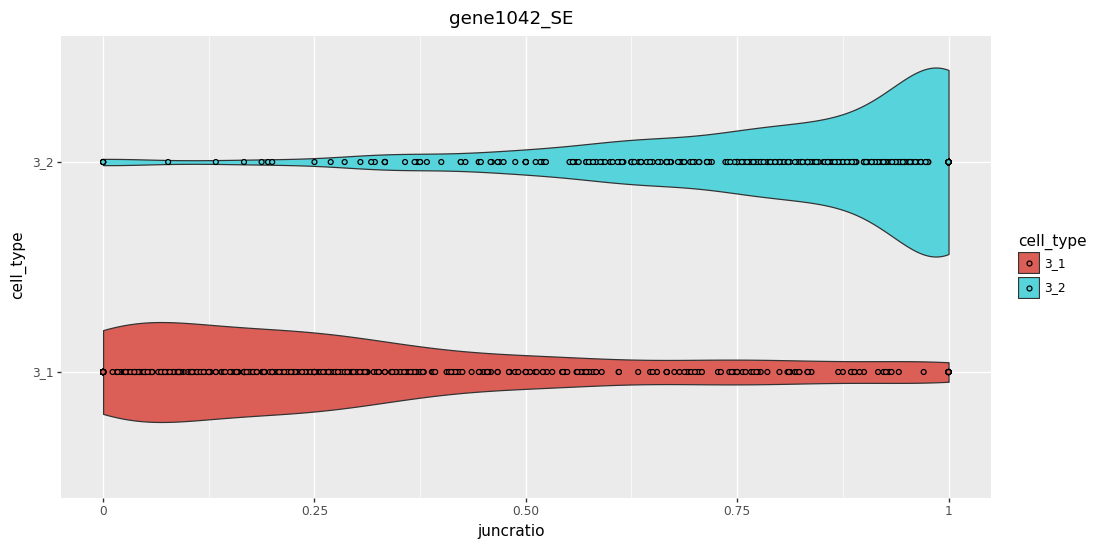


          junction_id_index  junction_id  Cluster
11041000                140  gene1042_SE       49


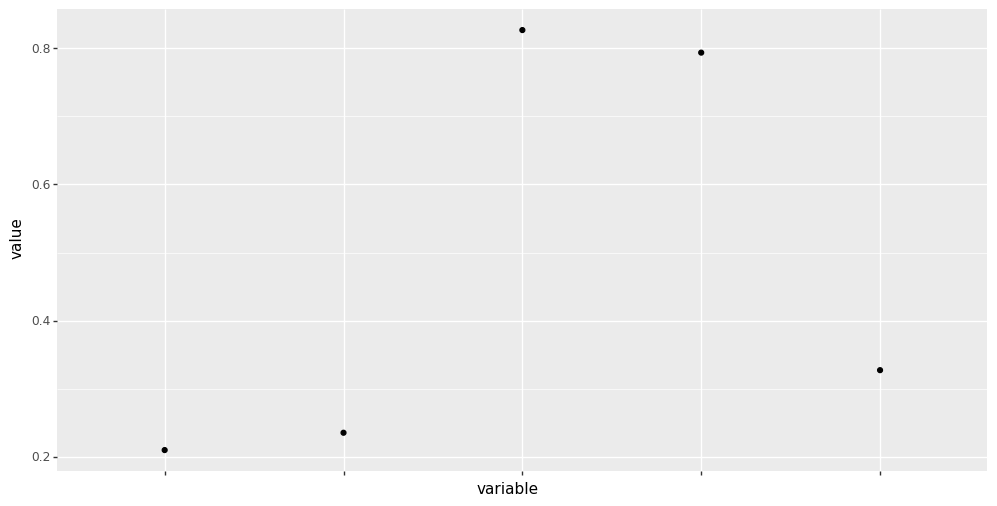


          junction_id_index  junction_id  Cluster
12331000               4434  gene2332_SE     1482
3_1    498
3_2    490
Name: cell_type, dtype: int64


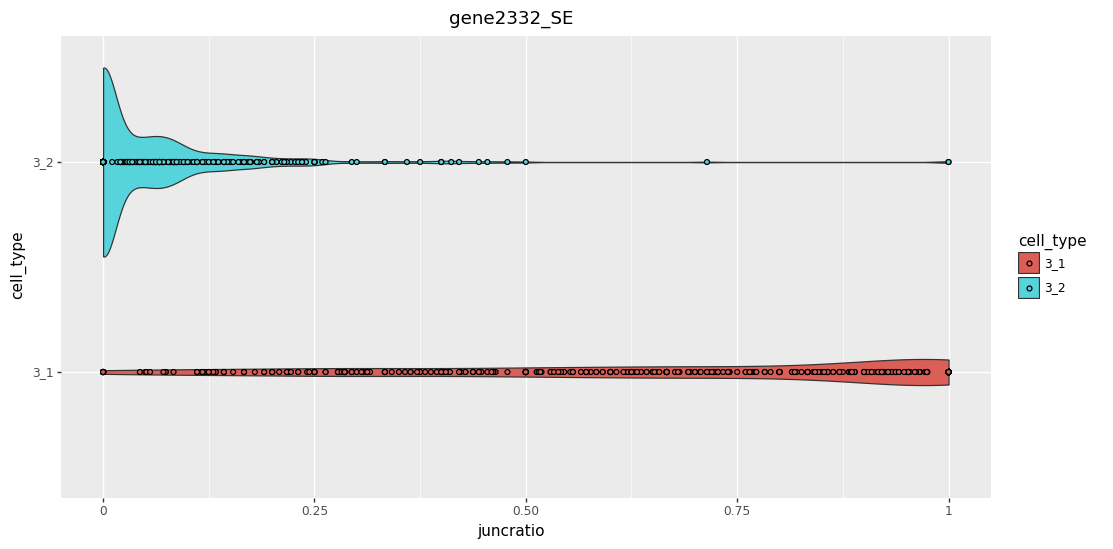


          junction_id_index  junction_id  Cluster
12331000               4434  gene2332_SE     1482


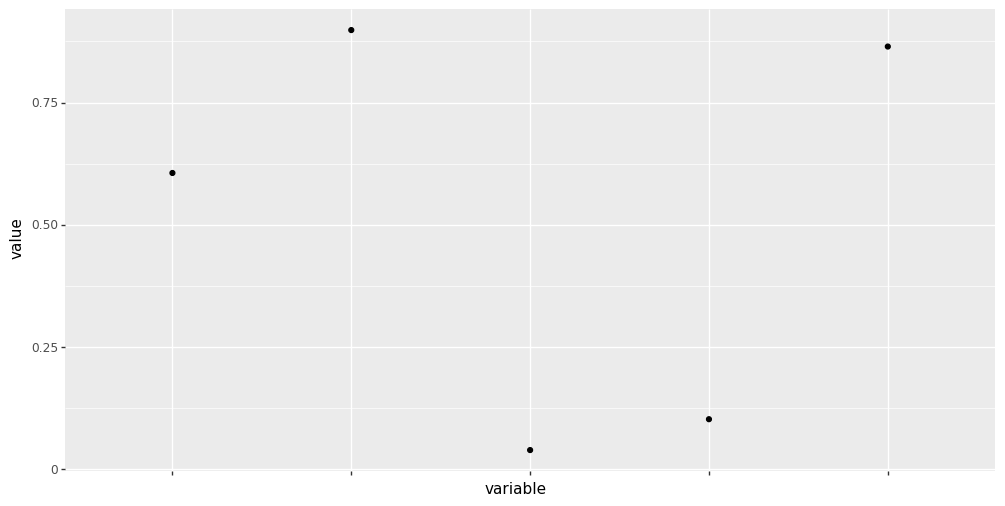

In [76]:
# for each junction in top10juncs_state1, run plot_juncObsUsage and plot_juncProbs
for junc in juncs_test:
    plot_juncObsUsage(junc)
    plot_juncProbs(junc)

In [77]:
scores_all_juncs_df

,score,junction_id_index
0,11.483398,0
1,19.134521,1
2,89.212158,2
3,3.584476,3
4,3.732599,4
...,...,...
14971,-0.660156,14971
14972,2.091187,14972
14973,87.277710,14973
14974,33.749756,14974


In [78]:
# let's map junction_id and gene to scores_all_juncs_df using full_data and rename the first column to LeafletScore 
junc_info = full_data[["junction_id_index", "junction_id", "gene"]].drop_duplicates()

In [79]:
scores_all_juncs_df.shape

(14976, 2)

In [80]:
junc_info = junc_info.merge(scores_all_juncs_df, on="junction_id_index").rename(columns={"score": "LeafletScore"}).sort_values(by="LeafletScore", ascending=False)

In [81]:
junc_info.head()

,junction_id_index,junction_id,gene,LeafletScore
11023,140,gene1042_SE,gene1042,7142.796875
12312,4434,gene2332_SE,gene2332,5955.942383
11903,3070,gene1923_SE,gene1923,5914.679688
11951,3229,gene1971_SE,gene1971,5148.136719
10212,4392,gene231_SE,gene231,4235.156250


In [82]:
junc_info[junc_info["junction_id_index"] == 0]

,junction_id_index,junction_id,gene,LeafletScore
997,0,gene1000_I1,gene1000,11.483398


In [83]:
junc_info.head()

,junction_id_index,junction_id,gene,LeafletScore
11023,140,gene1042_SE,gene1042,7142.796875
12312,4434,gene2332_SE,gene2332,5955.942383
11903,3070,gene1923_SE,gene1923,5914.679688
11951,3229,gene1971_SE,gene1971,5148.136719
10212,4392,gene231_SE,gene231,4235.156250


In [84]:
splicing_genes.head()

,GenePSI_Labels,gene
0,1,gene1
1,1,gene2
2,1,gene3
3,1,gene4
4,1,gene5


In [85]:
junc_info = junc_info.merge(splicing_genes, on="gene")
junc_info.head()

,junction_id_index,junction_id,gene,LeafletScore,GenePSI_Labels
0,140,gene1042_SE,gene1042,7142.796875,1
1,139,gene1042_I2,gene1042,2466.199219,1
2,138,gene1042_I1,gene1042,2264.503906,1
3,4434,gene2332_SE,gene2332,5955.942383,1
4,4432,gene2332_I1,gene2332,1592.728516,1


In [86]:
# subset juncs_probs_df where junction_id contains "gene1923" in it 
juncs_probs_df[juncs_probs_df["junction_id"].str.contains("gene1923")]

,cell_state_0,cell_state_1,cell_state_2,cell_state_3,cell_state_4,junction_id_index,junction_id
3068,0.109071,0.103255,0.345134,0.339753,0.066412,3068,gene1923_I1
3069,0.103728,0.102747,0.345068,0.332556,0.061010,3069,gene1923_I2
3070,0.787312,0.794507,0.309820,0.327757,0.872895,3070,gene1923_SE


In [87]:
# combine LeafletScore for junctions coming from the same gene --> get their mean, keep the GenePSILabels column 
junc_info_mean = junc_info.groupby(["gene", "GenePSI_Labels"]).agg({"LeafletScore": "mean"}).reset_index()
junc_info_mean.sort_values(by="LeafletScore", ascending=False).head(10), junc_info_mean.sort_values(by="LeafletScore", ascending=True).head(10)

(          gene  GenePSI_Labels  LeafletScore
 49    gene1042               1   3957.833333
 1027  gene1923               1   3295.832031
 1482  gene2332               1   3022.513346
 1080  gene1971               1   2630.000000
 952   gene1856               1   2268.111328
 912    gene182               1   2228.902995
 1457   gene231               1   2105.075521
 979   gene1880               1   1817.328288
 1218  gene2095               1   1621.214844
 1511  gene2359               1   1548.240234,
           gene  GenePSI_Labels  LeafletScore
 2786  gene3506               0     -7.687500
 3546  gene4190               0     -7.279297
 2475  gene3226               0     -7.268229
 2920  gene3627               0     -7.193359
 4104  gene4693               0     -7.027344
 2099  gene2889               0     -6.919596
 3014  gene3711               0     -6.760579
 2973  gene3675               0     -6.484375
 3743  gene4368               0     -6.473307
 4403  gene4962               0  

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).


<Axes: xlabel='LeafletScore', ylabel='Density'>

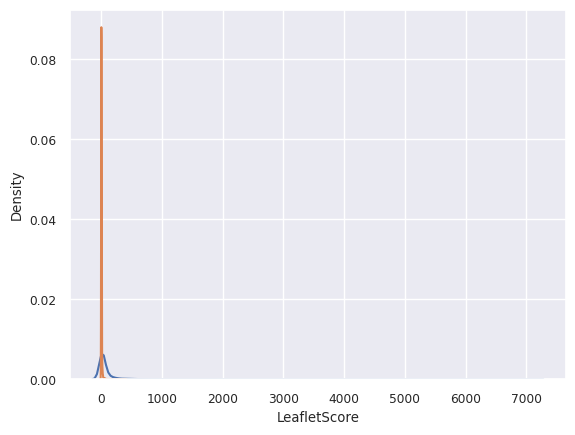

In [88]:
# plot the distribution of LeafletScore for each GenePSILabels
# show the density of LeafletScore across each GenePSI_Labels 
# use sns.distplot(data, hist=False)

sns.distplot(junc_info[junc_info["GenePSI_Labels"] == 1]["LeafletScore"], hist=False, label="PSI_Label_1")
sns.distplot(junc_info[junc_info["GenePSI_Labels"] == 0]["LeafletScore"], hist=False, label="PSI_Label_0")

In [89]:
from scipy.special import logit, expit
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

In [96]:
pre, rec, thres = precision_recall_curve(junc_info_mean["GenePSI_Labels"], junc_info_mean["LeafletScore"])
# Calculate AUC-ROC
auc_roc = roc_auc_score(junc_info_mean["GenePSI_Labels"], junc_info_mean["LeafletScore"])
auc_roc

0.9058920531384465

In [97]:
# visualize psi_table.loc['gene1128'] across all cells 
#plt.figure(figsize=(7, 5))
#plt.scatter(range(1000), platonic_psi.loc['gene2'], s=1, c='black')
#plt.xlabel('Cell')
#plt.ylabel('PSI')
# title should say simulate PSI for non-associated gene 
#plt.title('Simulated PSI for a positive cell-state associated gene')

0.8942463286173873

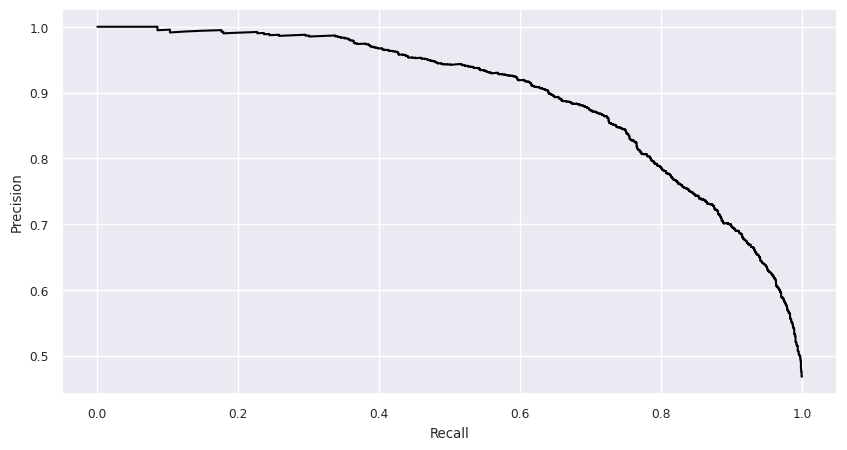

In [98]:
# plot precision recall curve using values calculated above
from sklearn.metrics import auc

plt.figure(figsize=(10, 5))
plt.plot(rec, pre, color='black')
plt.xlabel('Recall')
plt.ylabel('Precision')
auc_pr = auc(rec, pre)
auc_pr